In [9]:
import h5py
import numpy as np
from numpy import fft
from tqdm import tqdm
from matplotlib import pyplot as plt
from sigpy.mri.app import EspiritCalib
from matplotlib.gridspec import GridSpec
from utils_test import *
from utils import *
%matplotlib inline


# Data Load

In [10]:
path = './data/sample_0009.h5'


with h5py.File(path,'r') as hf:
    mask = hf['mask'][:]
    print(mask.shape)
    forward_fft           = hf['forward_fft'][:]
    csmp = hf['csmp'][:]

fn=lambda x: normalize01(np.abs(x))


# Mask Generation
ACS_lines = 24
R         = 4
mask, _ = create_undersampling_mask(forward_fft.shape[-1], forward_fft.shape[-2], R=R, ACS_lines=ACS_lines, mask_type='Cartesian', channels=csmp.shape[0])
mask = mask.transpose(2,0,1) 

    
    

"""
MRI Data Preprocessing Code
"""



# Step 1: Calculate zero-filled reconstruction for normalization
# Transform k-space to image domain for each coil
coils_img = np.fft.fftshift(
    np.fft.ifft2(
        np.fft.fftshift(forward_fft.transpose(1, 2, 0), axes=(0, 1)),
        axes=(0, 1)
    ),
    axes=(0, 1)
)

# Step 2: Calculate normalization factor using Root Sum of Squares (RSS)
NormFactor = np.max(np.sqrt(np.sum(np.abs(coils_img)**2, axis=2)))

# Step 3: Normalize k-space data
crop_data_full = forward_fft / NormFactor 
crop_mask = mask

# Step 4: Setup device and convert to PyTorch tensors
DEVICE = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')

# Transpose from (coil, row, col) to (row, col, coil) and convert to tensors
mask_tensor = torch.tensor(crop_mask.transpose(1, 2, 0)).to(DEVICE)
GT_ksp_tensor = torch.tensor(crop_data_full.transpose(1, 2, 0)).to(DEVICE).to(torch.complex64)
csmp_tensor = torch.tensor(csmp.transpose(1, 2, 0)).to(DEVICE).to(torch.complex64)

# Step 5: Calculate ground truth image by combining coil images with sensitivity maps
# Apply inverse FFT and coil combination
gt_img = torch.sum(
    torch.fft.fftshift(
        torch.fft.ifft2(
            torch.fft.fftshift(GT_ksp_tensor, dim=(0, 1)),
            dim=(0, 1)
        ),
        dim=(0, 1)
    ) * torch.conj(csmp_tensor),
    axis=2
).detach().cpu().numpy()

print(f"Ground truth image shape: {gt_img.shape}")

# Step 6: Create image domain mask based on coil sensitivity
csmp_mask = EspiritCalib((forward_fft)).run()  
normGT = fn(gt_img)
img_mask = np.zeros_like(normGT)
img_mask[csmp_mask[0] != 0] = 1


    

(14, 256, 256)
Ground truth image shape: (256, 256)


EspiritCalib:   0%|          | 0/100 [00:00<?, ?it/s]

# MRI Reconstruction based on SIREN with and without IPOD Initialization

In [14]:
lr_siren = 1e-4 
checkpoint_path_siren = './checkpoints/model_epoch_2500.pth'
epoch_SIREN  = 200
save_dir        = './result_save/'
save_iterations =[]

# IPOD Initialization
losses_SIREN_IPOD, pre_intensity_SIREN_IPOD, psnrs_SIREN_IPOD, ssims_SIREN_IPOD                                   =  run_test_siren(img_mask,gt_img, GT_ksp_tensor, mask_tensor, csmp_tensor, DEVICE, epoch_SIREN,step_size=100, 
                                                                                                                 TV_weight=2, lr = lr_siren, checkpoint_path=checkpoint_path_siren,save_dir=save_dir,save_iterations=save_iterations)

# Without IPOD Initialization
losses_SIREN, pre_intensity_SIREN, psnrs_SIREN, ssims_SIREN                                                       =  run_test_siren(img_mask,gt_img, GT_ksp_tensor, mask_tensor, csmp_tensor, DEVICE, epoch_SIREN,step_size=500, 
                                                                                                               TV_weight=2,   lr = lr_siren, checkpoint_path=None,save_dir=save_dir,save_iterations=save_iterations)


All parameters loaded
Ground truth saved to: ./result_save/ground_truth.png
(TRAIN0) Epoch[1/200], Lr:0.0001, Loss:2.636118
(TRAIN0) Epoch[2/200], Lr:0.0001, Loss:2.101319
(TRAIN0) Epoch[3/200], Lr:0.0001, Loss:1.762398
(TRAIN0) Epoch[4/200], Lr:0.0001, Loss:1.734794
(TRAIN0) Epoch[5/200], Lr:0.0001, Loss:1.580381
(TRAIN0) Epoch[6/200], Lr:0.0001, Loss:1.412216
(TRAIN0) Epoch[7/200], Lr:0.0001, Loss:1.391913
(TRAIN0) Epoch[8/200], Lr:0.0001, Loss:1.245740
(TRAIN0) Epoch[9/200], Lr:0.0001, Loss:1.235627
(TRAIN0) Epoch[10/200], Lr:0.0001, Loss:1.192638
(TRAIN0) Epoch[11/200], Lr:0.0001, Loss:1.124322
(TRAIN0) Epoch[12/200], Lr:0.0001, Loss:1.092422
(TRAIN0) Epoch[13/200], Lr:0.0001, Loss:1.056447
(TRAIN0) Epoch[14/200], Lr:0.0001, Loss:1.014880
(TRAIN0) Epoch[15/200], Lr:0.0001, Loss:0.998356
(TRAIN0) Epoch[16/200], Lr:0.0001, Loss:0.946613
(TRAIN0) Epoch[17/200], Lr:0.0001, Loss:0.936227
(TRAIN0) Epoch[18/200], Lr:0.0001, Loss:0.888520
(TRAIN0) Epoch[19/200], Lr:0.0001, Loss:0.883035
(T

# Metrics and Performance Curve

MAX psnr_meta:42.500
MAX ssim_meta:0.995
MAX psnr:31.463 
MAX ssim:0.970


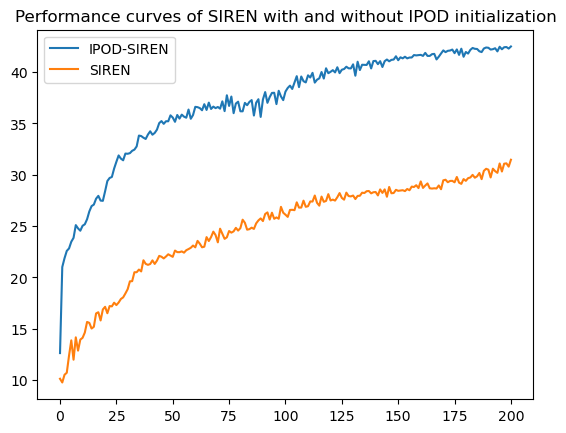

In [12]:
mode = 'SIREN'   

psnrs_meta = globals()[f'psnrs_{mode}_IPOD']
ssims_meta = globals()[f'ssims_{mode}_IPOD']
psnrs = globals()[f'psnrs_{mode}']
ssims = globals()[f'ssims_{mode}']
epoch_all = globals()[f'epoch_{mode}']

max_psnr_meta = max(psnrs_meta)
idx_psnr_meta = np.argmax(psnrs_meta)
max_psnr = max(psnrs)
idx_psnr = np.argmax(psnrs)

# Best Metrics
print(f'MAX psnr_meta:{max_psnr_meta:.3f}')
print(f'MAX ssim_meta:{ssims_meta[idx_psnr_meta]:.3f}')
print(f'MAX psnr:{max_psnr:.3f} ')
print(f'MAX ssim:{ssims[idx_psnr]:.3f}')


# Performance Curve
plt.plot(psnrs_meta, label=f'IPOD-{mode}')
plt.plot(psnrs, label=mode)
plt.title('Performance curves of SIREN with and without IPOD initialization')
plt.legend()
plt.show()



# Visualization

Text(0.5, 0.98, 'Reconstruction Comparison Based on SIREN')

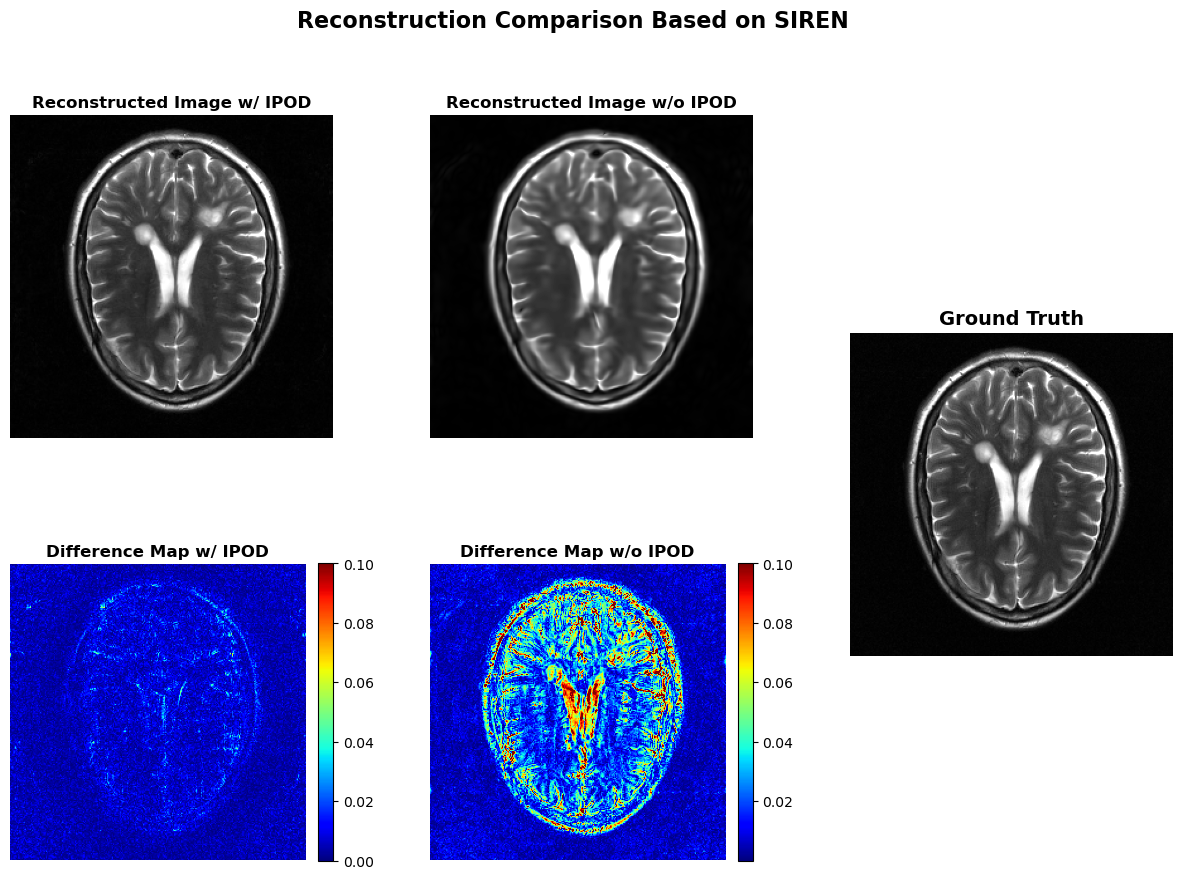

In [15]:
normOrg_IPOD   =fn(pre_intensity_SIREN_IPOD)
normOrg_origin =fn(pre_intensity_SIREN)

fig = plt.figure(figsize=(15, 10))
gs = GridSpec(2, 3, figure=fig, hspace=0.3, wspace=0.3)

# Left column and middle column: 2x2 grid for 4 images
ax1 = fig.add_subplot(gs[0, 0])  # Top-left: Original reconstruction
ax2 = fig.add_subplot(gs[0, 1])  # Top-middle: Origin version reconstruction
ax3 = fig.add_subplot(gs[1, 0])  # Bottom-left: Difference (normOrg_IPOD - normGT)
ax4 = fig.add_subplot(gs[1, 1])  # Bottom-middle: Difference (normOrg_origin - normGT)

# Right column: Ground truth (spanning both rows)
ax5 = fig.add_subplot(gs[:, 2])  # Full right column: Ground truth

# Plot 1: Original reconstruction
im1 = ax1.imshow((normOrg_IPOD), cmap='gray', vmax=0.7)
ax1.set_title('Reconstructed Image w/ IPOD', fontsize=12, fontweight='bold')
ax1.axis('off')

# Plot 2: Origin version reconstruction
im2 = ax2.imshow((normOrg_origin), cmap='gray', vmax=0.7)
ax2.set_title('Reconstructed Image w/o IPOD', fontsize=12, fontweight='bold')
ax2.axis('off')

# Plot 3: Difference map 1
im3 = ax3.imshow(np.abs(normOrg_IPOD - normGT), cmap='jet', vmax=0.1)
ax3.set_title('Difference Map w/ IPOD', fontsize=12, fontweight='bold')
ax3.axis('off')
plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)

# Plot 4: Difference map 2
im4 = ax4.imshow(np.abs(normOrg_origin - normGT), cmap='jet', vmax=0.1)
ax4.set_title('Difference Map w/o IPOD', fontsize=12, fontweight='bold')
ax4.axis('off')
plt.colorbar(im4, ax=ax4, fraction=0.046, pad=0.04)

# Plot 5: Ground truth (right column, full height)
im5 = ax5.imshow((normGT), cmap='gray', vmax=0.7)
ax5.set_title('Ground Truth', fontsize=14, fontweight='bold')
ax5.axis('off')

# Add overall title
fig.suptitle('Reconstruction Comparison Based on SIREN', fontsize=16, fontweight='bold', y=0.98)
